# Example 2 — Multi-Spacecraft Translational Simulation

This example demonstrates a simulation containing two spacecraft with independent translational propagators and navigation laws. SC1 is configured with SC2 as its target, illustrating the multi-spacecraft structure and target-state access.

### Notes and repository setup

Initial imports and repository-path configuration used by the example.

In [28]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## General Simulation Setup

ARGOS can work with multiple spacecrafts at a time, however, before defining any spacecraft, we need to define a common simulation setup

### Environment

The environment object provides the simulation environment in which the spacecraft dynamics are evaluated.

In [29]:
# Define the environment
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment() # NOTE: Need to review for proper implmentation of the environment class

### Simulation setup

The `Simulation` object defines the overall simulation horizon and environment. This works as a central orchestator for each spacecraft that will be added to the sim.

*Note: All the units in the simulations are in the Inertational Metric System*

In [30]:
from py.modules.new.simulation import Simulation

sim = Simulation(max_sim_time=3*60*60,                 
                 environment= env,                 
                 verbose = True
)

## Spacecraft 2 - Creation - SC2

As seen in the first example, several things need to be define depending on the detail wanted. In this case, as we just want a translational (orbital dynamics propagator), no actuators will be defined.

However, we will define an absolute sensor and a mission manager.

As this is a basic case, where there is just translational motion, no other GNC or phases will be defined. This translational motion, could be propagated under different dynamics equations, the most common, the basic two body relative problem, which can be used by setting the parameter `dynamics` to `REL2BP`

In [31]:
from py.modules.propagators.native_propagator import NativeTranslationalPropagator
from py.modules.sensors.generic_sensor import AbsoluteSensor

translational_propagator_SC2 = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")

dt_SC2 = 10 # Time step for the Spacecraft 2 in seconds

sensors_SC2 = [AbsoluteSensor(1/dt_SC2, verbose=False)]

In [32]:
from py.modules.navigation.basic_laws import IdealNavigation
from py.general.dataclasses import MissionPhase
from py.modules.new.mission_manager import MissionManager

nav_law_SC2 = IdealNavigation()

phase_SC2 = MissionPhase(
    name="Phase 1 - SC2",
    navigation=nav_law_SC2,
    dt_nav=dt_SC2,
    dt_propagation=dt_SC2,
    translational_model=translational_propagator_SC2
)

mission_manager_SC2 = MissionManager(
    initial_phase=phase_SC2
) 

We now define the initial conditions of an spacecraft in LEO, and we add the spacecraft to the simulation

In [33]:
initial_position_SC2 = np.array([0, 7000e3, 0])  # Initial position in meters
initial_velocity_SC2 = np.array([7.5e3, 0, 0])

sim.add_spacecraft(
    name="SC2",
    initial_position=initial_position_SC2,
    initial_velocity=initial_velocity_SC2,
    sensors=sensors_SC2,
    mission_manager=mission_manager_SC2,
)

Spacecraft 'SC2' added to the simulation.


## Spacecraft 1 - Creation - SC1

We will create an spacecraft equally to the Spacecraft 2, with the only difference that we will set the target of SC1 to be SC2

In [34]:
translational_propagator_SC1 = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")

dt_SC1 = 5 # Time step for the Spacecraft 1 in seconds

sensors_SC1 = [AbsoluteSensor(1/dt_SC1, verbose=False)]

nav_law_SC1 = IdealNavigation()

phase_SC1 = MissionPhase(
    name="Phase 1 - SC1",
    navigation=nav_law_SC1,
    dt_nav=dt_SC1,
    dt_propagation=dt_SC1,
    translational_model=translational_propagator_SC1
)

mission_manager_SC1 = MissionManager(
    initial_phase=phase_SC1
) 


initial_position_SC1 = np.array([7000e3, 0, 3500e3])  # Initial position in meters
initial_velocity_SC1 = np.array([0, 7.5e3, 0])

sim.add_spacecraft(
    name="SC1",
    initial_position=initial_position_SC1,
    initial_velocity=initial_velocity_SC1,
    sensors=sensors_SC1,
    mission_manager=mission_manager_SC1,
    target_name="SC2"
)

Target 'SC2' assigned to spacecraft 'SC1'.
Spacecraft 'SC1' added to the simulation.


## Simulation execution and results

We can now simulate and use some already built-in functions to graph the results.

Note how the ideal navigation corretly identifies the target position

In [35]:
# We can now simulate
result = sim.simulate()

Initializing simulation...
Spacecraft 'SC2' dt_nav: 10, dt_guid: nan, dt_control: nan
Spacecraft 'SC1' dt_nav: 5, dt_guid: nan, dt_control: nan
Simulation initialized.
Starting simulation...
Simulation completed.


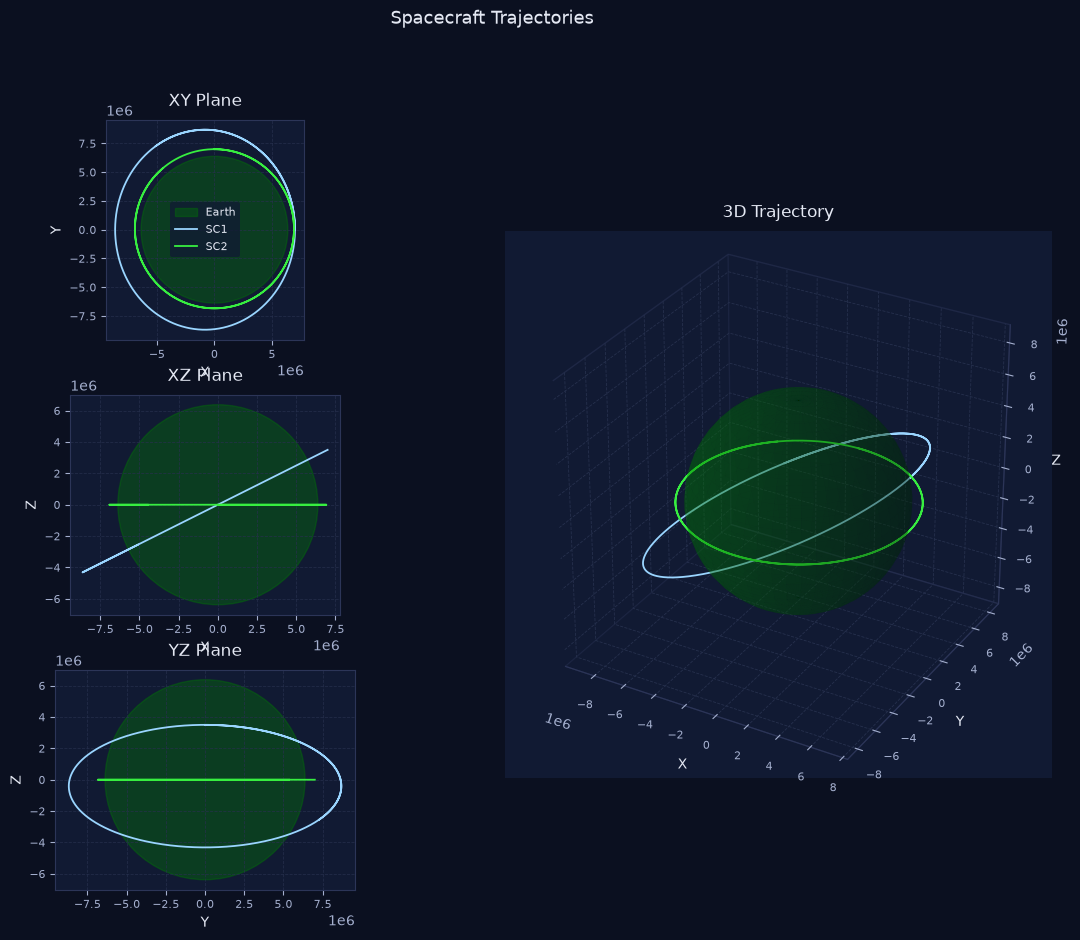

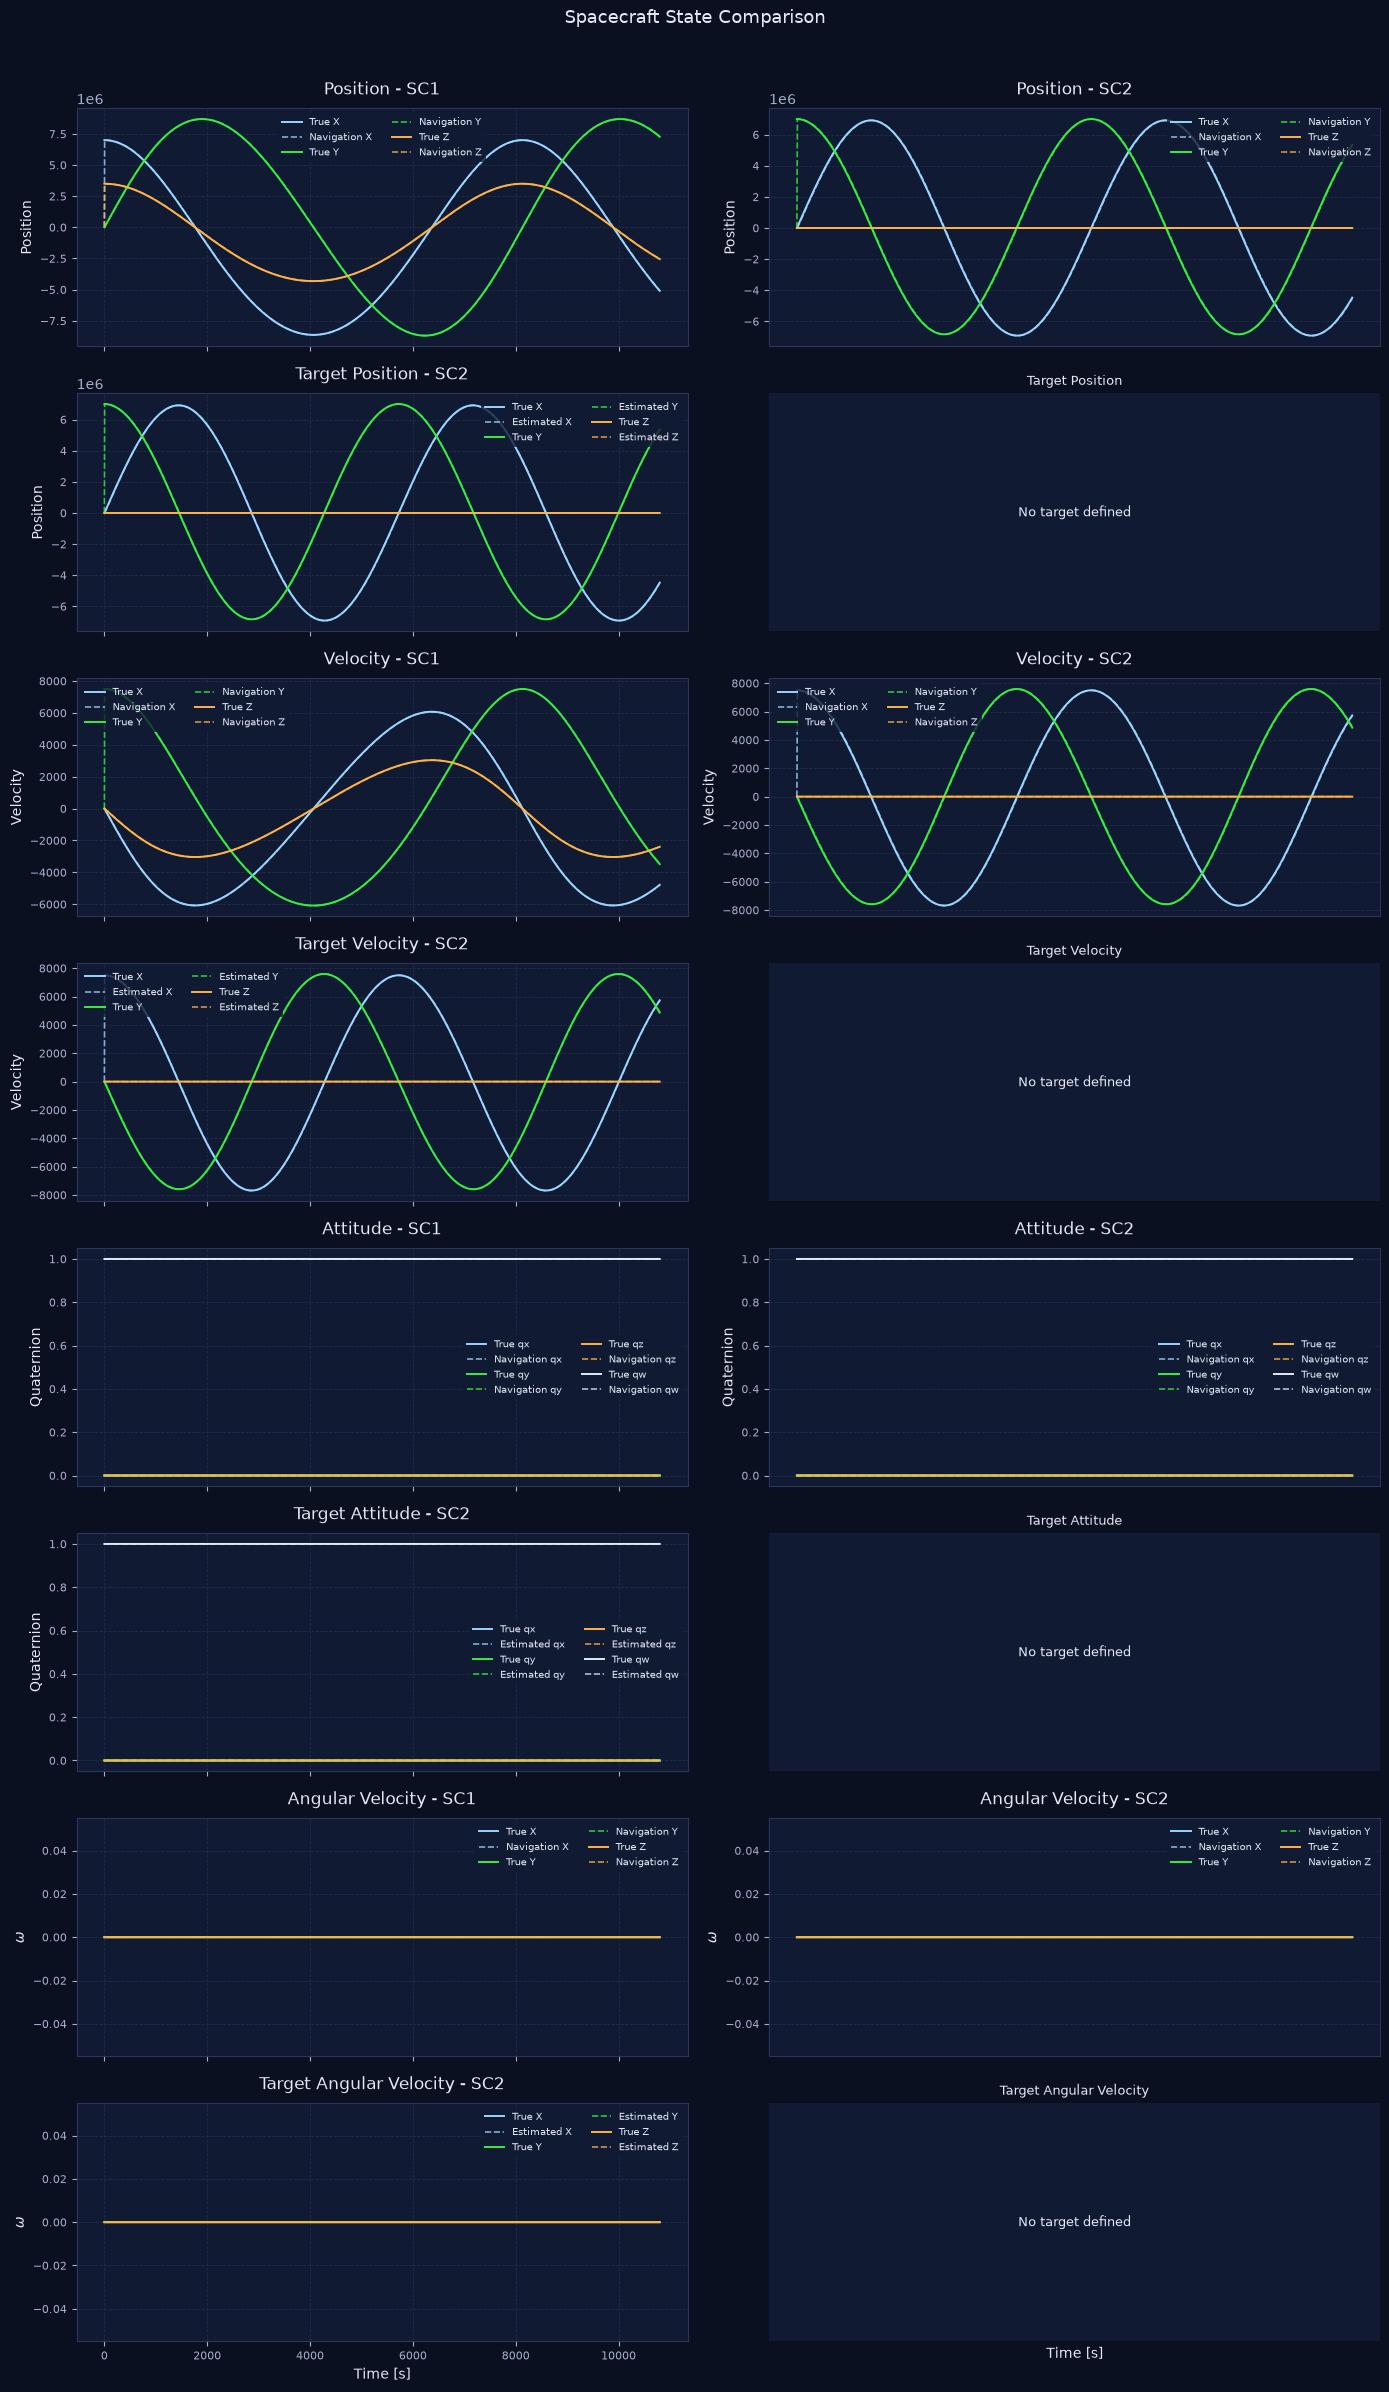

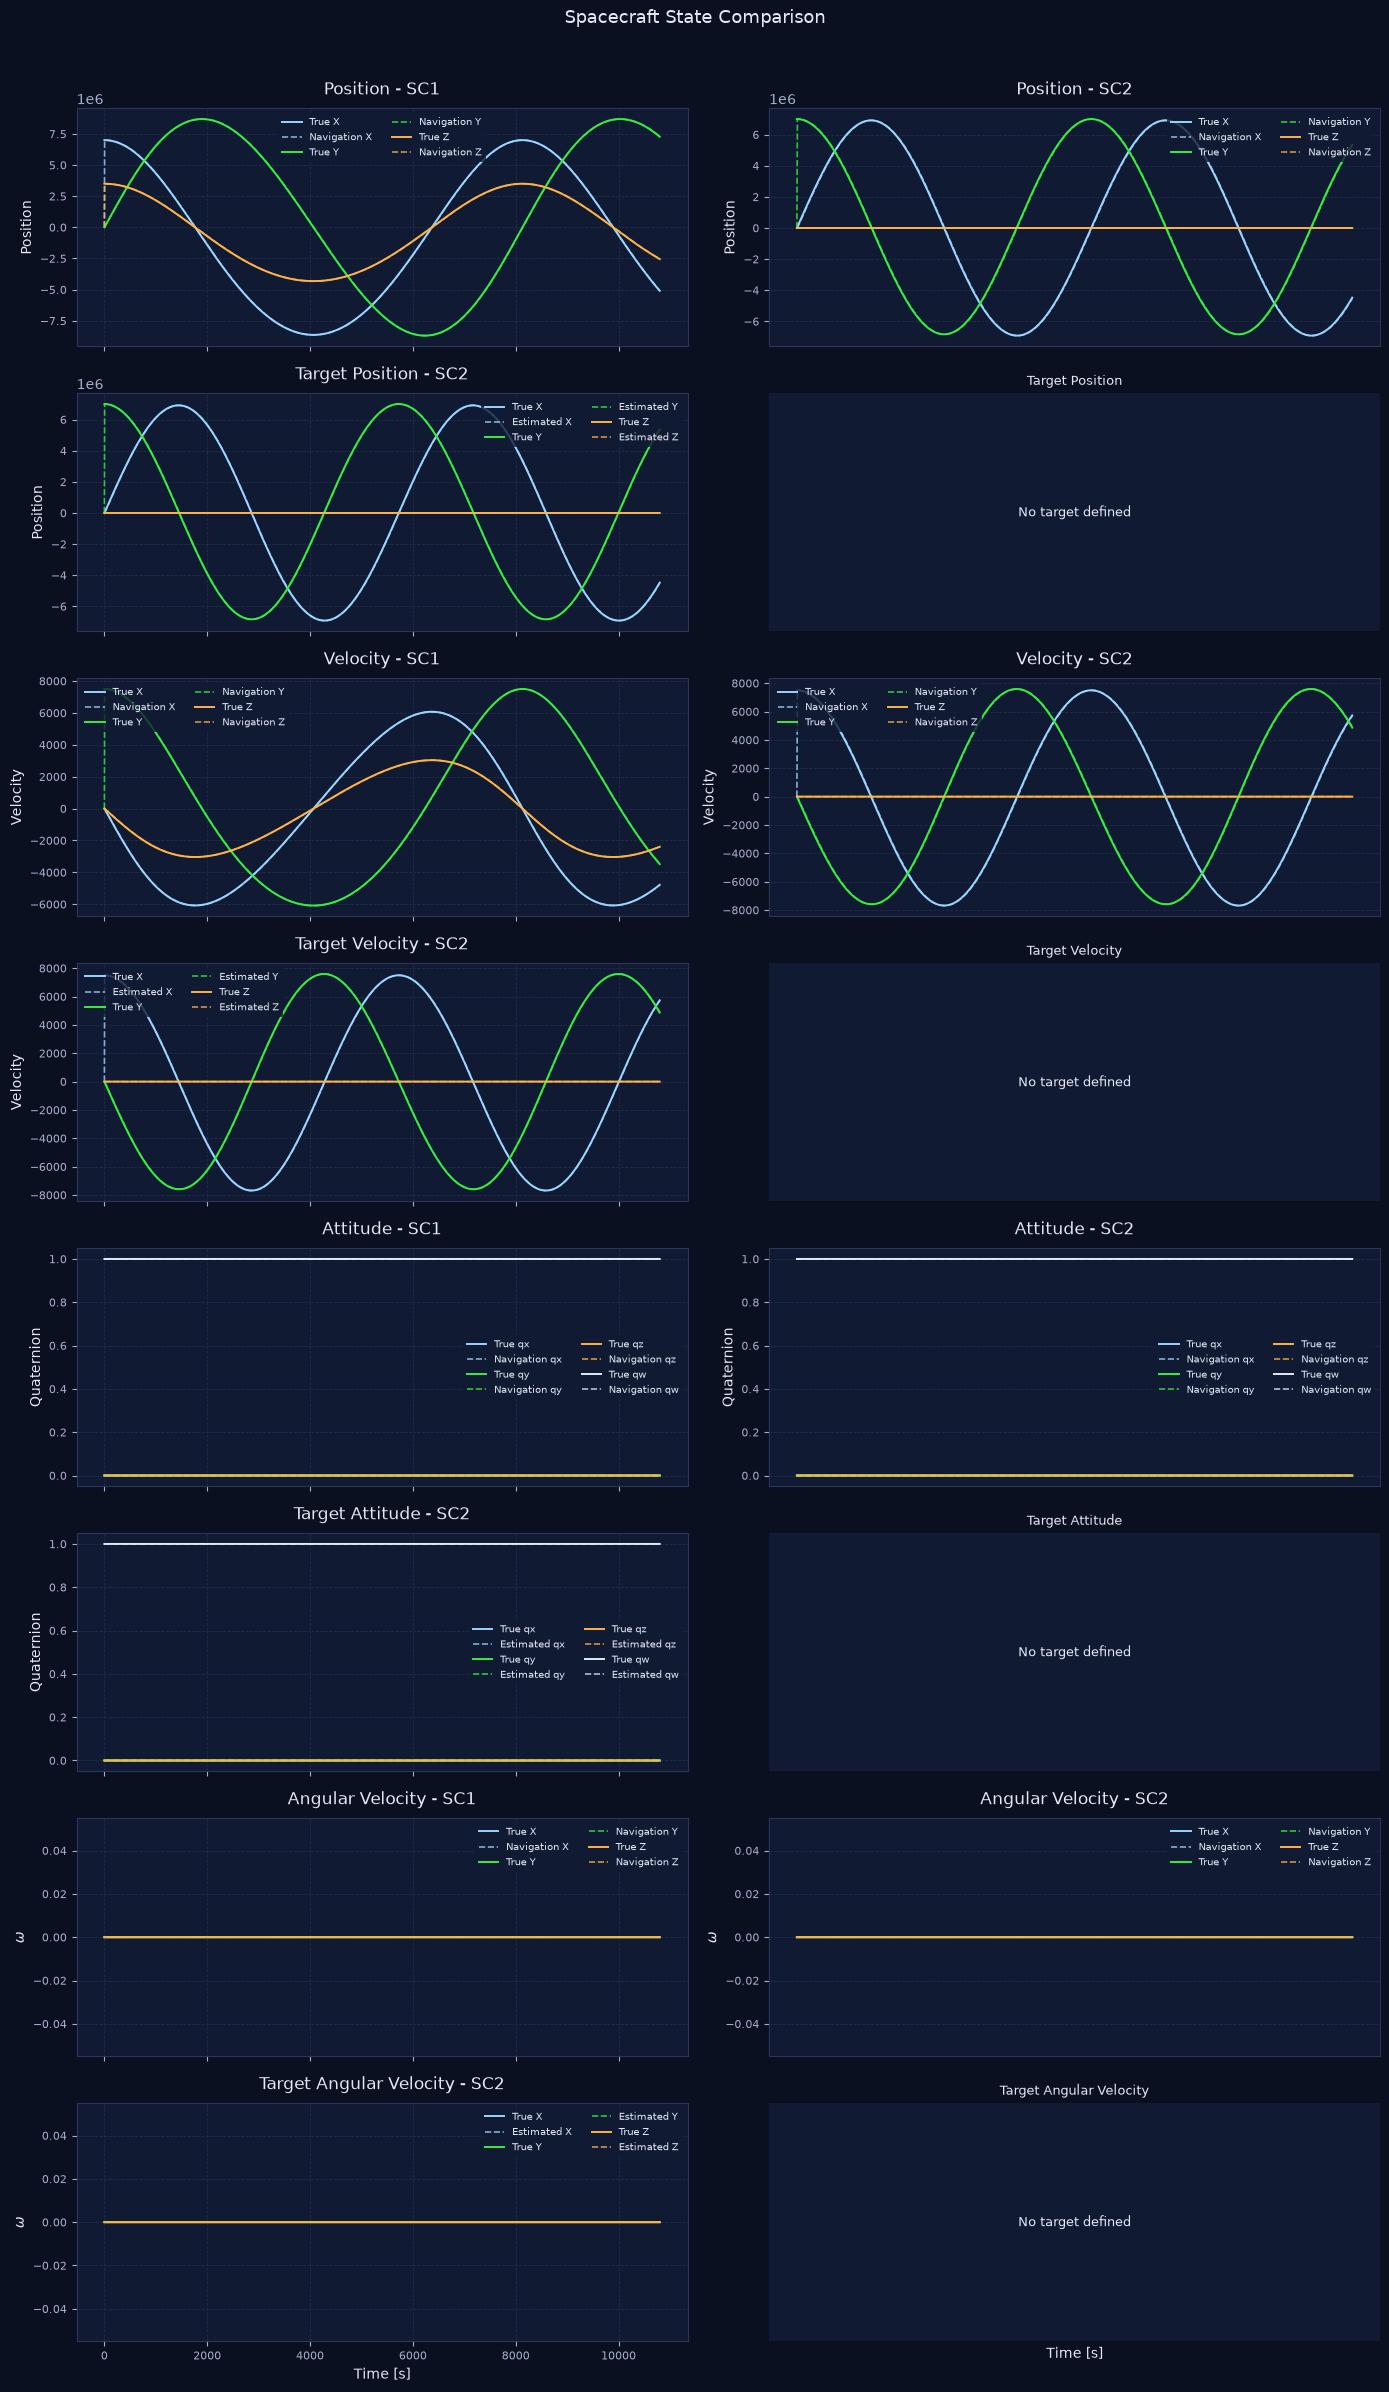

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# from py.modules.visualization.state_variables import plot_attitude_quaternions, plot_position

# plot_attitude_quaternions(["SC1", "SC2"], result, show=True)
# plot_position(["SC1", "SC2"], result, show=True)


from py.modules.visualization.trajectories import *

# plot_trajectory_xy(["SC1", "SC2"], result, show=True, body="Earth",)
# plot_trajectory_xz(["SC1", "SC2"], result, show=True, body="Earth",)
# plot_trajectory_yz(["SC1", "SC2"], result, show=True, body="Earth",)
# plot_trajectory_3d(["SC1", "SC2"], result, show=True, body="Earth",)
plot_trajectory(["SC1", "SC2"], result, show=True, body="Earth",)


from py.modules.visualization.gnc import *
plot_state_comparison(["SC1", "SC2"], result, show=True)